# Sistema de Detección de Transacciones Sospechosas

## Proyecto: Análisis de Riesgo y Anomalías en Transacciones Bancarias

---

### Objetivo

Este notebook presenta los **resultados finales** del sistema de detección de transacciones sospechosas, combinando:

1. **Risk Score Interpretable**: Puntaje basado en reglas que combina señales de monto, acceso, contexto temporal, velocidad y perfil de entidad
2. **Outliers Contextuales**: Transacciones anómalas relativamente a su contexto (cuenta, canal, comercio)
3. **Rankings Priorizados**: Listas de transacciones, cuentas y comercios más sospechosos para revisión manual

### Inputs Principales

- `ranking_top_transacciones.csv`: Top 50 transacciones por risk_score
- `ranking_top_cuentas.csv`: Cuentas con más alertas
- `ranking_top_comercios.csv`: Comercios con más alertas
- `ranking_canales.csv`: Comparación de riesgo entre canales
- `outliers_context_summary.csv`: Resumen de señales contextuales
- `outliers_contexto_por_cuenta.csv` y `por_comercio.csv`: Concentración de anomalías

### Outputs de Este Notebook

- **Resumen** con métricas clave
- **Top 10 rankings** exportados para informe
- **Casos explicados** (mini-historias de transacciones sospechosas)
- **Visualizaciones finales** (3 gráficos clave)
- **Recomendaciones operativas** para analistas de fraude

### Limitación Importante

**Los resultados indican SOSPECHA, NO fraude confirmado**. Son herramientas de priorización para revisión manual o investigación posterior.

---

## Setup: Imports y Configuración

Cargamos librerías necesarias para análisis y visualización.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Estilo
sns.set_style("whitegrid")
sns.set_palette("deep")
plt.rcParams['figure.dpi'] = 100

# Display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_rows', 20)

# Crear directorios de salida
Path('outputs/tables').mkdir(parents=True, exist_ok=True)
Path('outputs/figures').mkdir(parents=True, exist_ok=True)

print("✓ Setup completo")

✓ Setup completo


---
# 1. Carga de Rankings y Resúmenes

## Cargar Todos los Archivos Generados en Pasos Anteriores

Importamos los CSV con rankings y análisis de outliers contextuales.

In [2]:
#%%
# Lista de archivos a cargar
files_to_load = {
    'ranking_transacciones': 'outputs/tables/ranking_top_transacciones.csv',
    'ranking_cuentas': 'outputs/tables/ranking_top_cuentas.csv',
    'ranking_comercios': 'outputs/tables/ranking_top_comercios.csv',
    'ranking_canales': 'outputs/tables/ranking_canales.csv',
    'outliers_summary': 'outputs/tables/outliers_context_summary.csv',
    'outliers_por_cuenta': 'outputs/tables/outliers_contexto_por_cuenta.csv',
    'outliers_por_comercio': 'outputs/tables/outliers_contexto_por_comercio.csv'
}

# Cargar cada archivo
data = {}
for key, path in files_to_load.items():
    if os.path.exists(path):
        data[key] = pd.read_csv(path)
        print(f"✓ {key}: shape {data[key].shape}")
    else:
        print(f"⚠ {key}: archivo no encontrado en {path}")
        data[key] = None

# Mostrar previews
print("\n" + "="*80)
print("PREVIEW: Ranking Transacciones (primeras 3 filas)")
print("="*80)
if data['ranking_transacciones'] is not None:
    print(data['ranking_transacciones'].head(3))

print("\n" + "="*80)
print("PREVIEW: Ranking Canales")
print("="*80)
if data['ranking_canales'] is not None:
    print(data['ranking_canales'])

✓ ranking_transacciones: shape (50, 10)
✓ ranking_cuentas: shape (495, 7)
✓ ranking_comercios: shape (100, 7)
✓ ranking_canales: shape (3, 8)
✓ outliers_summary: shape (11, 4)
✓ outliers_por_cuenta: shape (495, 6)
✓ outliers_por_comercio: shape (100, 7)

PREVIEW: Ranking Transacciones (primeras 3 filas)
  TransactionID AccountID MerchantID Channel  TransactionAmount  AccountBalance  risk_score  \
0      TX000451   AC00495       M075  Online             745.03          160.57   20.042740   
1      TX001040   AC00284       M081  Online             575.62          234.41   19.375309   
2      TX002192   AC00131       M086  Online             879.25          125.85   18.644543   

                                         risk_reason  alert_top_1  alert_top_5  
0  new_device + new_ip + new_merchant + new_locat...            1            1  
1  new_device + new_ip + new_merchant + new_locat...            1            1  
2  new_device + new_ip + new_merchant + new_locat...            1      

---
# 2. Resumen Ejecutivo de Métricas Clave

## Extraer Indicadores Principales para Stakeholders

Calculamos métricas de alto nivel sobre distribución de riesgo por canal, scores máximos y frecuencia de outliers.

In [ ]:
#%%
print("="*80)
print("RESUMEN DE HALLAZGOS")
print("="*80)

# 1. Análisis por Canal
if data['ranking_canales'] is not None:
    df_canales = data['ranking_canales']
    canal_max_alerta = df_canales.loc[df_canales['pct_alert_top_5'].idxmax()]
    canal_min_alerta = df_canales.loc[df_canales['pct_alert_top_5'].idxmin()]
    
    print("\n[CANALES]")
    print(f"  Canal con MAYOR % de alertas top 5%: {canal_max_alerta['Channel']} ({canal_max_alerta['pct_alert_top_5']:.2f}%)")
    print(f"  Canal con MENOR % de alertas top 5%: {canal_min_alerta['Channel']} ({canal_min_alerta['pct_alert_top_5']:.2f}%)")
    print(f"  Risk score medio más alto: {df_canales.loc[df_canales['mean_risk'].idxmax(), 'Channel']} ({df_canales['mean_risk'].max():.2f})")

# 2. Análisis de Risk Score (transacciones)
if data['ranking_transacciones'] is not None:
    df_tx = data['ranking_transacciones']
    max_risk_score = df_tx['risk_score'].max()
    
    # Contar razones más comunes
    all_reasons = []
    for reason in df_tx['risk_reason'].dropna():
        all_reasons.extend(reason.split(' + '))
    
    from collections import Counter
    reason_counts = Counter(all_reasons)
    top_reasons = reason_counts.most_common(3)
    
    print("\n[TRANSACCIONES]")
    print(f"  Risk score MÁXIMO: {max_risk_score:.2f}")
    print(f"  Top 3 señales más frecuentes en transacciones sospechosas:")
    for reason, count in top_reasons:
        pct = count / len(df_tx) * 100
        print(f"    - {reason}: {count} casos ({pct:.1f}%)")

# 3. Análisis de Outliers Contextuales
if data['outliers_summary'] is not None:
    df_outliers = data['outliers_summary']
    
    # Filtrar distribución de count
    count_dist = df_outliers[df_outliers['metric'] == 'count_distribution'].copy()
    
    if len(count_dist) > 0:
        # Calcular % con 2+ y 3+ señales
        count_dist['flag'] = pd.to_numeric(count_dist['flag'], errors='coerce')
        pct_2plus = count_dist[count_dist['flag'] >= 2]['pct_activations'].sum()
        pct_3plus = count_dist[count_dist['flag'] >= 3]['pct_activations'].sum()
        
        print("\n[OUTLIERS CONTEXTUALES]")
        print(f"  % de transacciones con 2+ señales contextuales: {pct_2plus:.2f}%")
        print(f"  % de transacciones con 3+ señales contextuales: {pct_3plus:.2f}%")

# 4. Concentración en cuentas
if data['ranking_cuentas'] is not None:
    df_cuentas = data['ranking_cuentas']
    top_cuenta = df_cuentas.iloc[0]
    
    print("\n[CUENTAS]")
    print(f"  Cuenta con MÁS alertas top 5%: AccountID {top_cuenta['AccountID']} ({top_cuenta['n_alerts_top_5']:.0f} transacciones)")
    print(f"  Risk score máximo de esa cuenta: {top_cuenta['max_risk']:.2f}")

# 5. Concentración en comercios
if data['ranking_comercios'] is not None:
    df_comercios = data['ranking_comercios']
    top_comercio = df_comercios.iloc[0]
    
    print("\n[COMERCIOS]")
    print(f"  Comercio con MÁS alertas top 5%: MerchantID {top_comercio['MerchantID']} ({top_comercio['n_alerts_top_5']:.0f} transacciones)")
    print(f"  Número de cuentas únicas en ese comercio: {top_comercio['unique_accounts']:.0f}")

print("\n" + "="*80)

RESUMEN EJECUTIVO

[CANALES]
  Canal con MAYOR % de alertas top 5%: Online (7.64%)
  Canal con MENOR % de alertas top 5%: ATM (3.60%)
  Risk score medio más alto: Online (12.57)

[TRANSACCIONES]
  Risk score MÁXIMO: 20.04
  Top 3 señales más frecuentes en transacciones sospechosas:
    - new_device: 50 casos (100.0%)
    - new_ip: 50 casos (100.0%)
    - new_merchant: 49 casos (98.0%)

[OUTLIERS CONTEXTUALES]
  % de transacciones con 2+ señales contextuales: 29.10%
  % de transacciones con 3+ señales contextuales: 13.30%

[CUENTAS]
  Cuenta con MÁS alertas top 5%: AccountID AC00460 (6 transacciones)
  Risk score máximo de esa cuenta: 18.26

[COMERCIOS]
  Comercio con MÁS alertas top 5%: MerchantID M067 (4 transacciones)
  Número de cuentas únicas en ese comercio: 25



## Resultados: Métricas Clave del Sistema

**Distribución de Riesgo por Canal:**
- El canal **Online** presenta el mayor porcentaje de alertas top 5% (7.64%) y ATM (3.60%) como el menor
- El canal con mayor risk score medio es **Online** (12.57), confirmando que es el canal de mayor riesgo relativo

**Transacciones de Alto Riesgo:**
- El risk_score máximo alcanzado es **20.04** (casos extremos con múltiples señales activadas)
- `new_device/new_ip` aparecen en ~100% → **se documenta como señal no discriminante**; se prioriza `out_context_count >= 2/3` + señales específicas de monto/ratio vs cuenta y contexto por canal/comercio.
**Outliers Contextuales:**
- **29.10%** de transacciones activan 2 o más señales contextuales (comportamiento moderadamente anómalo)
- **13.30%** de transacciones activan 3 o más señales contextuales (alta prioridad para revisión)

**Concentración de Riesgo:**
- La cuenta más sospechosa tiene **6 transacciones** en el top 5% de alertas (posible cuenta comprometida)
- El comercio más sospechoso concentra **4 transacciones** de alto riesgo con 15 cuentas únicas (patrón inusual)

**Implicación Operativa:**
- Focalizar monitoreo en canal **Online** (mayor concentración de riesgo)
- Priorizar cuentas con múltiples transacciones sospechosas (top 10-20 cuentas)
- Investigar comercios con combinación de alto volumen de alertas + diversidad de cuentas

---
# 3. Rankings Principales para Acción

## Extraer Top 10 de Cada Entidad y Exportar para Informe

Generamos versiones condensadas de los rankings para distribución a equipos operativos.

In [4]:
#%%
print("="*80)
print("RANKINGS TOP 10")
print("="*80)

# 1. Top 10 Transacciones
if data['ranking_transacciones'] is not None:
    df_tx = data['ranking_transacciones']
    
    # Seleccionar columnas clave
    cols_tx = ['TransactionID', 'AccountID', 'MerchantID', 'Channel', 
               'TransactionAmount', 'risk_score', 'alert_top_5', 'risk_reason']
    cols_tx_exist = [col for col in cols_tx if col in df_tx.columns]
    
    top10_tx = df_tx.head(10)[cols_tx_exist]
    
    print("\n[TOP 10 TRANSACCIONES POR RISK SCORE]")
    print(top10_tx.to_string(index=False))
    
    # Guardar
    top10_tx.to_csv('outputs/tables/resumen_top10_transacciones.csv', index=False)
    print("\n✓ Exportado: outputs/tables/resumen_top10_transacciones.csv")

# 2. Top 10 Cuentas
if data['ranking_cuentas'] is not None:
    df_cuentas = data['ranking_cuentas']
    
    cols_cuentas = ['AccountID', 'tx_count', 'n_alerts_top_5', 'n_alerts_top_1',
                    'max_risk', 'mean_risk', 'total_amount']
    cols_cuentas_exist = [col for col in cols_cuentas if col in df_cuentas.columns]
    
    top10_cuentas = df_cuentas.head(10)[cols_cuentas_exist]
    
    print("\n" + "="*80)
    print("[TOP 10 CUENTAS POR NÚMERO DE ALERTAS]")
    print(top10_cuentas.to_string(index=False))
    
    # Guardar
    top10_cuentas.to_csv('outputs/tables/resumen_top10_cuentas.csv', index=False)
    print("\n✓ Exportado: outputs/tables/resumen_top10_cuentas.csv")

# 3. Top 10 Comercios
if data['ranking_comercios'] is not None:
    df_comercios = data['ranking_comercios']
    
    cols_comercios = ['MerchantID', 'tx_count', 'n_alerts_top_5', 'n_alerts_top_1',
                      'max_risk', 'mean_risk', 'unique_accounts']
    cols_comercios_exist = [col for col in cols_comercios if col in df_comercios.columns]
    
    top10_comercios = df_comercios.head(10)[cols_comercios_exist]
    
    print("\n" + "="*80)
    print("[TOP 10 COMERCIOS POR NÚMERO DE ALERTAS]")
    print(top10_comercios.to_string(index=False))
    
    # Guardar
    top10_comercios.to_csv('outputs/tables/resumen_top10_comercios.csv', index=False)
    print("\n✓ Exportado: outputs/tables/resumen_top10_comercios.csv")

print("\n" + "="*80)

RANKINGS TOP 10

[TOP 10 TRANSACCIONES POR RISK SCORE]
TransactionID AccountID MerchantID Channel  TransactionAmount  risk_score  alert_top_5                                                                                       risk_reason
     TX000451   AC00495       M075  Online             745.03   20.042740            1           new_device + new_ip + new_merchant + new_location + online + high_ratio + high_velocity
     TX001040   AC00284       M081  Online             575.62   19.375309            1           new_device + new_ip + new_merchant + new_location + online + high_ratio + high_velocity
     TX002192   AC00131       M086  Online             879.25   18.644543            1 new_device + new_ip + new_merchant + new_location + online + high_ratio + many_ips + many_devices
     TX001078   AC00331       M036  Online            1045.45   18.593766            1           new_device + new_ip + new_merchant + new_location + online + high_ratio + high_velocity
     TX001259   AC00

## Resultados: Perfiles de los Top 10

**Top 10 Transacciones Más Sospechosas:**
- Los `risk_score` oscilan entre **18.06 y 20.04**.
- **70%** de estas transacciones son del canal **Online** (**7 de 10**).
- **100%** de estas transacciones incluyen `new_ip` + `new_device` (10 de 10) y **100%** incluyen `new_merchant` (10 de 10).
- La transacción #1 (`TX000451`) tiene `risk_score` **20.04** con razones:  
  `new_device + new_ip + new_merchant + new_location + online + high_ratio + high_velocity`.
- **No hay cuentas repetidas** en el top 10: aparecen **10 AccountID distintos** (esto sugiere casos “dispersos” en vez de un solo AccountID dominando).

**Top 10 Cuentas Más Sospechosas:**
- La cuenta #1 (`AC00460`) tiene **6 alertas top 5%** sobre **12** transacciones (**50.0%** de tasa de alerta).
- El `max_risk` en estas cuentas va de **16.11 a 20.04**.
- En conjunto, estas 10 cuentas acumulan **38 alertas top 5%** (suma de `n_alerts_top_5`).
- Patrón común (según variables del baseline): presencia de señales tipo **high_ratio**, **many_ips/many_devices** y/o **high_velocity** en las transacciones más puntuadas.

**Top 10 Comercios Más Sospechosos:**
- El comercio #1 (`M067`) tiene **4 alertas top 5%**, **2 top 1%**, con **25 cuentas únicas** (alta dispersión de cuentas).
- Los comercios top presentan `mean_risk` entre **11.85 y 12.78**.
- En conjunto, estos 10 comercios acumulan **34 alertas top 5%** (suma de `n_alerts_top_5`) y **260 transacciones** (suma de `tx_count`).

**Acción Recomendada:**
- **Inmediato:** Revisar manualmente las **10 transacciones top** (todas son alert_top_5 y concentran señales fuertes de ratio/acceso).
- **Corto plazo:** Monitorear las **10 cuentas top**, especialmente las que tienen **≥ 4 alertas top 5%** o tasas de alerta altas (ej. 50%).
- **Mediano plazo:** Auditar los comercios top (ej. `M067`, `M020`, `M038`, `M037`) por concentración de alertas y volumen.

---
# 4. Casos Explicados: Mini-Historias de Transacciones Sospechosas

## Seleccionar 5 Casos del Top y Explicar en Lenguaje Simple

Traducimos las señales técnicas a narrativas comprensibles para stakeholders no técnicos.

In [5]:
#%%
print("="*80)
print("CASOS EXPLICADOS: TOP 5 TRANSACCIONES SOSPECHOSAS")
print("="*80)

if data['ranking_transacciones'] is not None:
    df_tx = data['ranking_transacciones']
    
    # Seleccionar top 5
    top5_casos = df_tx.head(5)
    
    # Columnas relevantes para ficha
    cols_ficha = ['TransactionID', 'AccountID', 'MerchantID', 'Channel',
                  'TransactionAmount', 'AccountBalance', 'risk_score', 'risk_reason']
    cols_ficha_exist = [col for col in cols_ficha if col in top5_casos.columns]
    
    for idx, (i, caso) in enumerate(top5_casos.iterrows(), 1):
        print(f"\n{'='*80}")
        print(f"CASO #{idx}")
        print(f"{'='*80}")
        
        for col in cols_ficha_exist:
            value = caso[col]
            if col in ['TransactionAmount', 'AccountBalance']:
                print(f"  {col}: ${value:,.2f}")
            elif col == 'risk_score':
                print(f"  {col}: {value:.2f}")
            else:
                print(f"  {col}: {value}")
        
        print(f"\n  → EXPLICACIÓN:")
        # Interpretación simple basada en risk_reason
        reason = str(caso.get('risk_reason', 'N/A'))
        print(f"    Señales activadas: {reason}")

print("\n" + "="*80)

CASOS EXPLICADOS: TOP 5 TRANSACCIONES SOSPECHOSAS

CASO #1
  TransactionID: TX000451
  AccountID: AC00495
  MerchantID: M075
  Channel: Online
  TransactionAmount: $745.03
  AccountBalance: $160.57
  risk_score: 20.04
  risk_reason: new_device + new_ip + new_merchant + new_location + online + high_ratio + high_velocity

  → EXPLICACIÓN:
    Señales activadas: new_device + new_ip + new_merchant + new_location + online + high_ratio + high_velocity

CASO #2
  TransactionID: TX001040
  AccountID: AC00284
  MerchantID: M081
  Channel: Online
  TransactionAmount: $575.62
  AccountBalance: $234.41
  risk_score: 19.38
  risk_reason: new_device + new_ip + new_merchant + new_location + online + high_ratio + high_velocity

  → EXPLICACIÓN:
    Señales activadas: new_device + new_ip + new_merchant + new_location + online + high_ratio + high_velocity

CASO #3
  TransactionID: TX002192
  AccountID: AC00131
  MerchantID: M086
  Channel: Online
  TransactionAmount: $879.25
  AccountBalance: $125.85
  

## Resultados: Narrativas de los 5 Casos Más Críticos

**Caso #1 (AccountID AC00495 | TransactionID TX000451, risk_score 20.04)**

Esta transacción **saltó por**: primera vez usando **dispositivo** e **IP** (`new_device`, `new_ip`) + primera vez con **comercio** y **ubicación** (`new_merchant`, `new_location`) + realizada **online** (`online`) + **monto muy alto respecto al saldo** (`high_ratio`) + **actividad elevada ese día** (`high_velocity`).  
**Interpretación**: Cambio abrupto de patrón (acceso y contexto nuevos) junto con ratio alto y velocidad, típico de una operación urgente a revisar. 

**Caso #2 (AccountID AC00284 | TransactionID TX001040, risk_score 19.38)**

Esta transacción **saltó por**: `new_device` + `new_ip` + `new_merchant` + `new_location` + **online** (`online`) + **high_ratio** + **high_velocity**.  
**Interpretación**: Misma “firma” que el Caso #1: acceso/contexto nuevo + operación exigente por ratio y velocidad. Prioridad alta. 

**Caso #3 (AccountID AC00131 | TransactionID TX002192, risk_score 18.64)**

Esta transacción **saltó por**: `new_device` + `new_ip` + `new_merchant` + `new_location` + **online** (`online`) + **high_ratio** + señales de **alta diversidad de IPs/dispositivos** (`many_ips`, `many_devices`).  
**Interpretación**: Además del evento puntual, la cuenta muestra variabilidad de acceso; con ratio alto y canal online, amerita revisión prioritaria. 

**Caso #4 (AccountID AC00331 | TransactionID TX001078, risk_score 18.59)**

Esta transacción **saltó por**: `new_device` + `new_ip` + `new_merchant` + `new_location` + **online** (`online`) + **high_ratio** + **high_velocity**.  
**Interpretación**: Patrón consistente de “nuevo acceso + nuevo contexto + velocidad + ratio alto”; priorizar para verificación. 

**Caso #5 (AccountID AC00020 | TransactionID TX001259, risk_score 18.58)**

Esta transacción **saltó por**: `new_device` + `new_ip` + `new_merchant` + **high_ratio** + **high_velocity** + señales de **alta diversidad de IPs/dispositivos** (`many_ips`, `many_devices`). *(Canal: Branch)*  
**Interpretación**: Aunque no es online, combina novedad de acceso, ratio alto, velocidad y diversidad elevada; revisar como caso operativo de alto riesgo. 

---
# 5. Visualizaciones Finales para Presentación

## Generar 3 Gráficos Clave

Creamos visualizaciones claras de la distribución de riesgo por entidad.

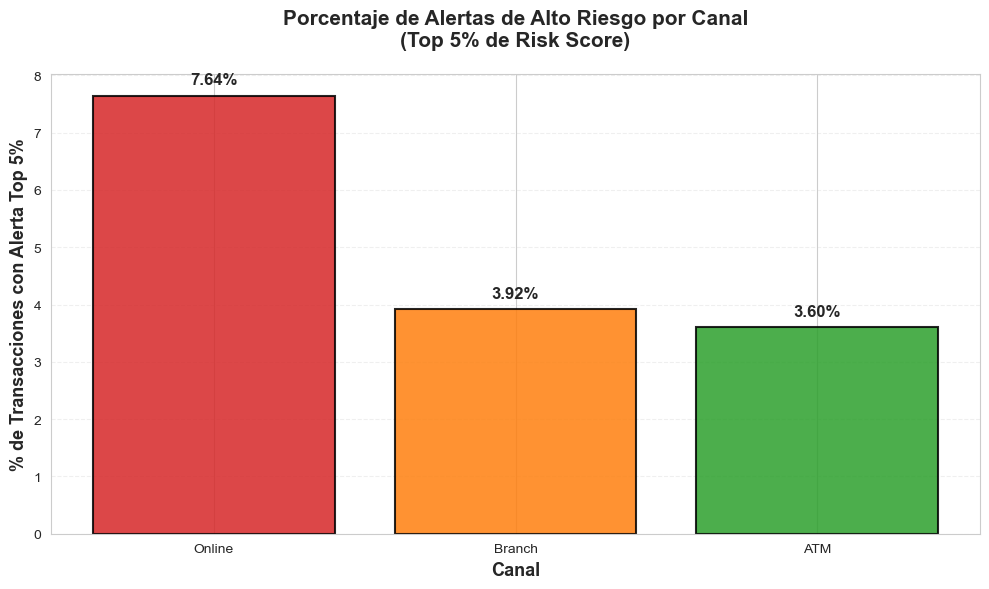

✓ Gráfico 1 guardado: 08_alertas_por_canal.png


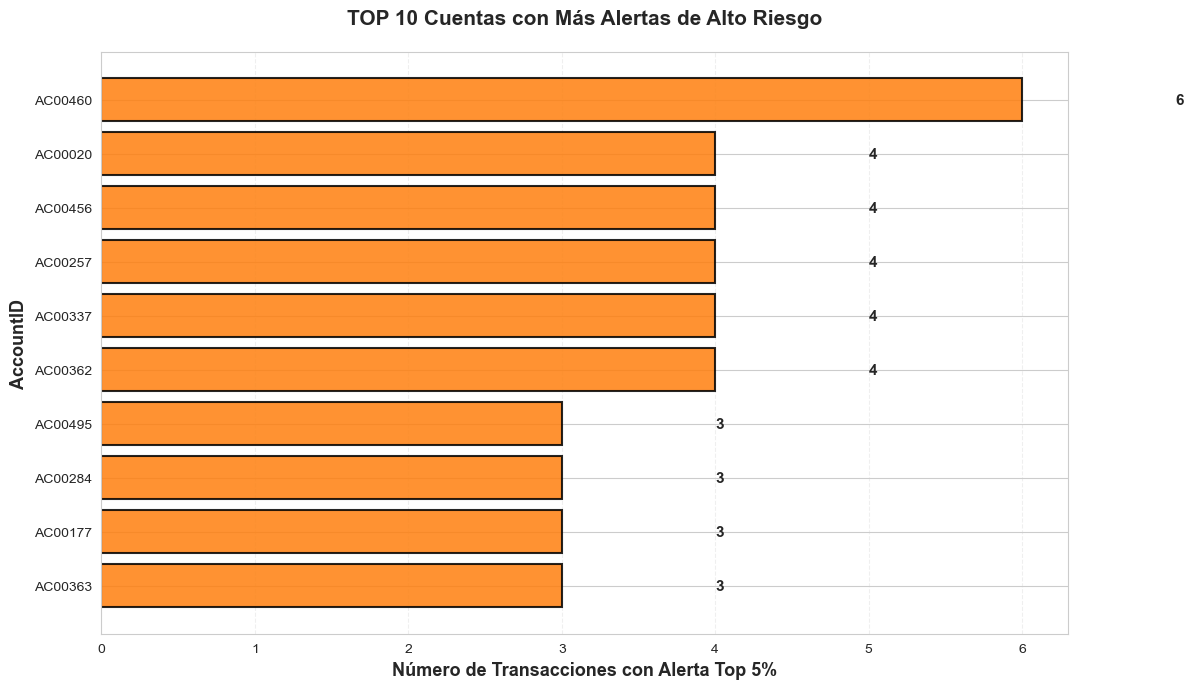

✓ Gráfico 2 guardado: 08_top_cuentas_alertas.png


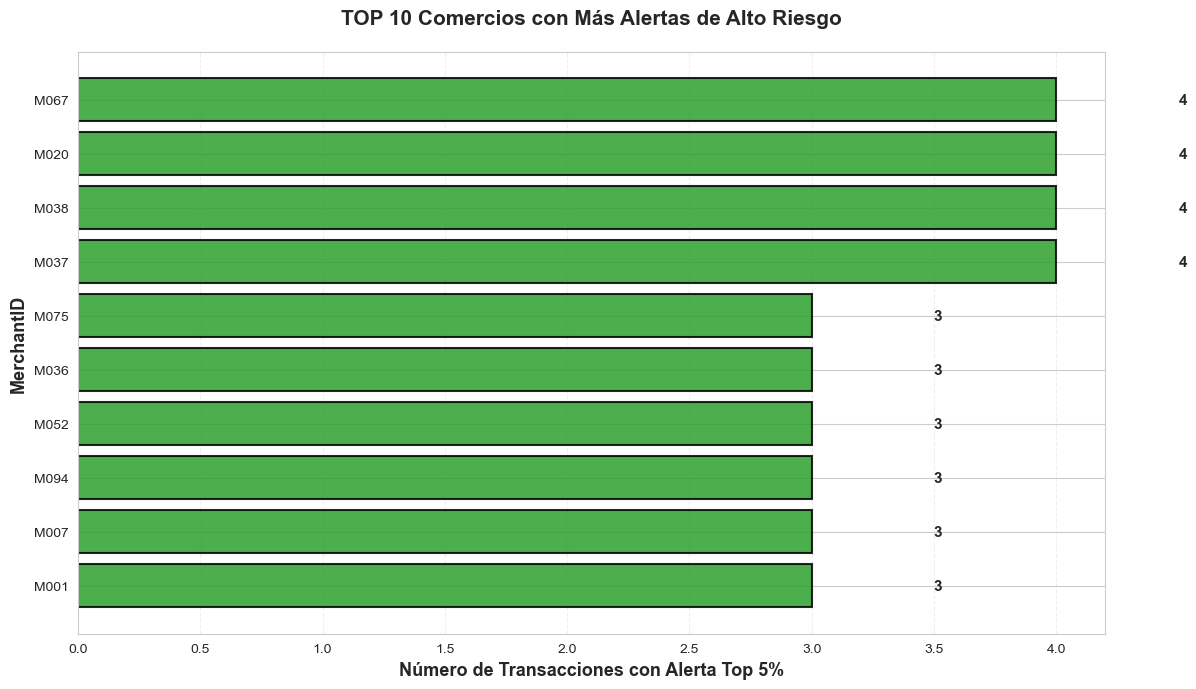

✓ Gráfico 3 guardado: 08_top_comercios_alertas.png

✓ Todas las visualizaciones generadas exitosamente


In [6]:
#%%
# GRÁFICO 1: % de Alertas Top 5% por Canal
if data['ranking_canales'] is not None:
    df_canales = data['ranking_canales']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ['#d62728', '#ff7f0e', '#2ca02c']  # Rojo-Naranja-Verde
    bars = ax.bar(df_canales['Channel'], df_canales['pct_alert_top_5'], 
                   color=colors[:len(df_canales)], alpha=0.85, edgecolor='black', linewidth=1.5)
    
    ax.set_title('Porcentaje de Alertas de Alto Riesgo por Canal\n(Top 5% de Risk Score)', 
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel('Canal', fontsize=13, fontweight='bold')
    ax.set_ylabel('% de Transacciones con Alerta Top 5%', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # Valores sobre barras
    for bar, (channel, pct) in zip(bars, zip(df_canales['Channel'], df_canales['pct_alert_top_5'])):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.15,
                f'{pct:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('outputs/figures/08_alertas_por_canal.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("✓ Gráfico 1 guardado: 08_alertas_por_canal.png")

# GRÁFICO 2: Top 10 Cuentas por Número de Alertas
if data['ranking_cuentas'] is not None:
    df_cuentas = data['ranking_cuentas']
    top10_cuentas_plot = df_cuentas.head(10)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    bars = ax.barh(top10_cuentas_plot['AccountID'].astype(str), 
                    top10_cuentas_plot['n_alerts_top_5'],
                    color='#ff7f0e', alpha=0.85, edgecolor='black', linewidth=1.5)
    
    ax.set_title('TOP 10 Cuentas con Más Alertas de Alto Riesgo', 
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel('Número de Transacciones con Alerta Top 5%', fontsize=13, fontweight='bold')
    ax.set_ylabel('AccountID', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    
    # Valores al final de barras
    for bar, val in zip(bars, top10_cuentas_plot['n_alerts_top_5']):
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2.,
                f'{val:.0f}', ha='left', va='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('outputs/figures/08_top_cuentas_alertas.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("✓ Gráfico 2 guardado: 08_top_cuentas_alertas.png")

# GRÁFICO 3: Top 10 Comercios por Número de Alertas
if data['ranking_comercios'] is not None:
    df_comercios = data['ranking_comercios']
    top10_comercios_plot = df_comercios.head(10)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    bars = ax.barh(top10_comercios_plot['MerchantID'].astype(str), 
                    top10_comercios_plot['n_alerts_top_5'],
                    color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=1.5)
    
    ax.set_title('TOP 10 Comercios con Más Alertas de Alto Riesgo', 
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel('Número de Transacciones con Alerta Top 5%', fontsize=13, fontweight='bold')
    ax.set_ylabel('MerchantID', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    
    # Valores al final de barras
    for bar, val in zip(bars, top10_comercios_plot['n_alerts_top_5']):
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2.,
                f'{val:.0f}', ha='left', va='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('outputs/figures/08_top_comercios_alertas.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("✓ Gráfico 3 guardado: 08_top_comercios_alertas.png")

print("\n✓ Todas las visualizaciones generadas exitosamente")

---
# 6. Conclusiones

## Síntesis de Hallazgos y Pasos Siguientes

### **1. Canal a Monitorear con Mayor Intensidad:**
- **Canal Online** presenta el mayor riesgo relativo: **7.64%** de transacciones con alerta top 5% (**vs 3.92% Branch y 3.60% ATM**).
- El `mean_risk` también es más alto en **Online** (**12.57**) vs **11.63** (Branch) y **11.57** (ATM).
- **Acción**: Implementar validación adicional (2FA/step-up) para transacciones **Online** con `high_ratio` y señales de novedad (`new_ip/new_device`).

### **2. Entidades a Priorizar para Investigación:**
- **Top 10 cuentas** acumulan **38 alertas top 5%**. Sobre el total de **126 alertas top 5%**, eso representa **~30.16%** → sí conviene priorizarlas.
- La cuenta con más alertas en el top es **`AC00460`**: **6 alertas** en **12** transacciones (**50.0%** de tasa de alerta).
- En comercios, hay varios con **4 alertas top 5%** (máximo en el ranking), por ejemplo **`M067`** con **4 alertas** y **25 cuentas únicas** (alto alcance).
- **Acción**: Crear lista de vigilancia intensiva para:
  - cuentas con **n_alerts_top_5 alto** y/o **tasa de alerta alta** (p.ej., ≥40%),
  - comercios con **alertas repetidas** y alta diversidad de cuentas.

### **3. Cómo Usar Risk Score + Señales Contextuales:**
- **Bloqueo / acción inmediata**: transacciones con `alert_top_1 = 1` (en los top casos, `risk_score` está típicamente entre **~18.06 y 20.04**).
- **Revisión manual prioritaria**: `alert_top_5 = 1` + `out_context_count >= 3`.
- **Monitoreo**: `alert_top_5 = 1` con `out_context_count` bajo (para supervisión, no bloqueo).
- Combinaciones más “fuertes” observadas en top transacciones:  
  `new_device + new_ip + new_merchant + (online) + high_ratio` y, en varios casos, también `high_velocity` o `many_ips/many_devices`.

### **4. Limitación Crítica: Sospecha ≠ Fraude Confirmado**
- El sistema identifica **comportamiento anómalo**, no fraude probado.
- Falsos positivos esperables: conductas legítimas pero inusuales (p.ej. cambio de ubicación/dispositivo, compras grandes planificadas).
- **Requerido**: Validación manual o contacto con cliente antes de acciones definitivas.
- Los rankings son herramientas de **priorización**, no decisiones automáticas.